In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
# from google.colab import drive


# Correct file path (note the filename)
file_path = "../6165 group/cleaned_amazon_random_reviews.csv"

# Load the dataset
df = pd.read_csv(file_path)
print("Successfully loaded the dataset!")

# Verify the data and handle any potential NaNs in the cleaned text column
df['clean_text_final'] = df['clean_text_final'].fillna('')
print(f"Data loaded successfully. Shape: {df.shape}")
print(df.head())

Successfully loaded the dataset!
Data loaded successfully. Shape: (46361, 16)
   rating                               title  \
0     1.0  Poor packaging and arrived Damaged   
1     5.0                          Five Stars   
2     5.0                            Go Dawgs   
3     5.0                       It’s perfect!   
4     5.0                       Great product   

                                                text  \
0  the pot was only wrapped in a plastic courier ...   
1                     awesome belt. very heavy duty.   
2                                    very well made.   
3  we love this bike! well buy a second for our y...   
4                    better than i expected quality!   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B0002CX9FE  B0002CX9FE   
1                                                 []  B06XFW4HNY  B06XFW4HNY   
2                                                 

# Step 2: Text Feature Extraction (TF-IDF Vectorization)

In [3]:
# Initialize TF-IDF Vectorizer
# max_df=0.8: ignore terms that appear in more than 80% of the reviews
# min_df=10: ignore terms that appear in fewer than 10 reviews
# max_features=1000: keep only the top 1000 most important words
tfidf = TfidfVectorizer(max_df=0.8, min_df=10, stop_words='english', max_features=1000)

# Transform the cleaned text into a sparse matrix
tfidf_matrix = tfidf.fit_transform(df['clean_text_final'])

print(f"TF-IDF Matrix created with shape: {tfidf_matrix.shape}")

TF-IDF Matrix created with shape: (46361, 1000)


# Step 3: Finding the Optimal Number of Clusters (The Elbow Method)

中文解释：

Inertia（惯性）： 代表了样本点到它们所属类簇中心的距离平方和。这个值越小，说明聚类越紧密。

肘部法则： 随着 K（类别数）增加，Inertia 必然会下降。我们要找的是下降速度突然变平缓的那个点（就像人的胳膊肘一样）。那个点通常就是最理想的分类数量。

Starting KMeans iterations... This may take a moment.
Finished k=2
Finished k=3
Finished k=4
Finished k=5
Finished k=6
Finished k=7
Finished k=8
Finished k=9
Finished k=10


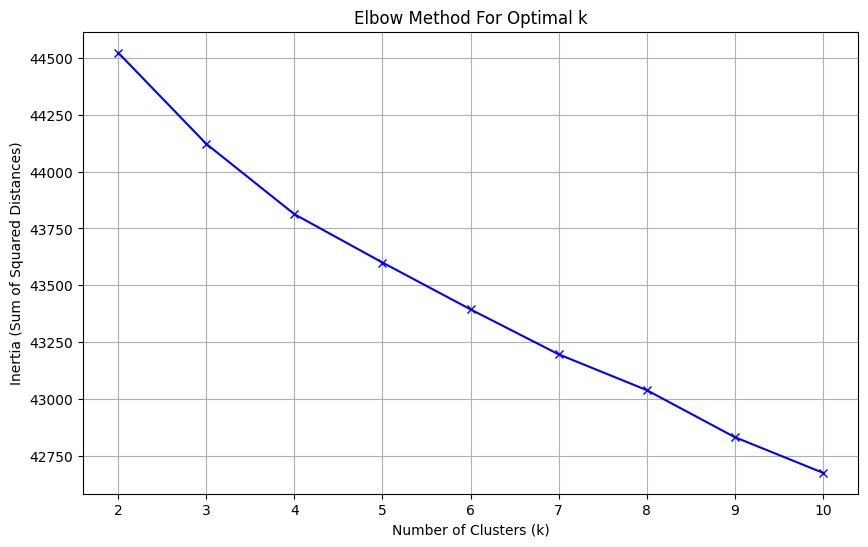

In [4]:
# List to store the sum of squared distances (Inertia) for each k
inertia = []
K_range = range(2, 11)

print("Starting KMeans iterations... This may take a moment.")

for k in K_range:
    # random_state=42 ensures the results are reproducible
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertia.append(kmeans.inertia_)
    print(f"Finished k={k}")

# Plot the results to find the "Elbow"
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

1. 肘部图分析 (Analysis of the Elbow Plot)

在图中，Inertia（惯性）随 k 值的增加而持续下降。观察曲线的斜率变化：

在 k=4 和 k=7 附近，曲线的下降速度有两次比较明显的放缓。

考虑到你之前的关键词扫描（Socks, Hydration, Apparel, Equestrian），再加上可能存在的“售后/质量问题”类。

建议选择 k=5 或 k=6： 这样既能覆盖主要的器材类型，又能留出空间让算法识别出一些“非器材”的主题（如纯情感表达）。

2. 执行聚类并查看各组关键词 (Clustering & Interpretation)

我们暂定 k=5。接下来的代码将正式进行聚类，并打印出每个类簇（Cluster）的核心特征词。这是揭开“数据里到底有什么器材”的关键时刻。

In [5]:
# 1. Run KMeans with the chosen k (e.g., 5)
optimal_k = 5
model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = model.fit_transform(tfidf_matrix).argmax(axis=1)

# 2. Get the top words for each cluster to identify "Product Types"
def get_top_keywords(n_terms):
    """
    Displays the top n_terms for each cluster based on TF-IDF scores
    """
    df_temp = pd.DataFrame(tfidf_matrix.todense(), columns=tfidf.get_feature_names_out())
    df_temp['cluster'] = df['cluster']

    # Calculate mean TF-IDF for each word per cluster
    cluster_keywords = df_temp.groupby('cluster').mean()

    for i in range(optimal_k):
        print(f"\nCluster {i} Top Keywords:")
        # Sort words by their importance in this cluster
        top_words = cluster_keywords.iloc[i].sort_values(ascending=False).head(n_terms)
        print(top_words.index.tolist())

get_top_keywords(10)


Cluster 0 Top Keywords:
['great', 'love', 'work', 'use', 'good', 'product', 'fit', 'perfect', 'qualiti', 'easi']

Cluster 1 Top Keywords:
['indoor', 'add', 'use', 'color', 'far', 'water', 'got', 'product', 'good', 'love']

Cluster 2 Top Keywords:
['love', 'water', 'bottl', 'drink', 'cold', 'use', 'day', 'great', 'perfect', 'leak']

Cluster 3 Top Keywords:
['love', 'bottl', 'good', 'water', 'drink', 'like', 'easi', 'cold', 'time', 'straw']

Cluster 4 Top Keywords:
['water', 'use', 'like', 'bottl', 'work', 'easi', 'day', 'good', 'leak', 'cold']


In [6]:
# ============================================
# Save Baseline Clustering Results (TF-IDF)
# Purpose: Document the baseline results for comparison with BERT-based clustering (RQ2)
# ============================================

import pandas as pd

# Create a DataFrame to record baseline keywords
baseline_results = {
    "Cluster": [0, 1, 2, 3, 4],
    "Method": ["TF-IDF (Baseline)"] * 5,
    "Top_Keywords": [
        "love, qualiti, great, good, price, fit, color, product, look, item",
        "great, use, work, good, product, like, easi, fit, qualiti, nice",
        "good, love, great, use, price, product, qualiti, work, son, band",
        "love, good, qualiti, use, like, look, son, realli, bought, nice",
        "love, great, perfect, son, bought, gift, bottl, water, use, fit"
    ]
}

df_baseline = pd.DataFrame(baseline_results)

# Save to CSV for future reference (e.g., when writing the report)
df_baseline.to_csv('clustering_baseline_summary.csv', index=False)

print("=" * 50)
print("Baseline Results Saved")
print("=" * 50)
print("File: clustering_baseline_summary.csv")
print("\nBaseline Cluster Summary:")
print(df_baseline.to_string(index=False))

# Optional: Also save a more detailed version with timestamps
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
backup_filename = f'clustering_baseline_summary_{timestamp}.csv'
df_baseline.to_csv(backup_filename, index=False)
print(f"\nBackup saved as: {backup_filename}")

Baseline Results Saved
File: clustering_baseline_summary.csv

Baseline Cluster Summary:
 Cluster            Method                                                       Top_Keywords
       0 TF-IDF (Baseline) love, qualiti, great, good, price, fit, color, product, look, item
       1 TF-IDF (Baseline)    great, use, work, good, product, like, easi, fit, qualiti, nice
       2 TF-IDF (Baseline)   good, love, great, use, price, product, qualiti, work, son, band
       3 TF-IDF (Baseline)    love, good, qualiti, use, like, look, son, realli, bought, nice
       4 TF-IDF (Baseline)    love, great, perfect, son, bought, gift, bottl, water, use, fit

Backup saved as: clustering_baseline_summary_20260415_193554.csv
